<a href="https://www.kaggle.com/code/lalit7881/ai-vs-human-text-classification-2026-eda-100?scriptVersionId=316331843" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alitaqishah/ai-vs-human-text-classification-dataset-2026/ai_vs_human_text_2026.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/alitaqishah/ai-vs-human-text-classification-dataset-2026/ai_vs_human_text_2026.csv')

In [3]:
df.head()

,text_id,label,source_model,domain,text_content,topic_hint,word_count,avg_sentence_length,generation_method
0,TXT_0001,human,human,social,can we talk about gene editing ethics for a se...,gene editing ethics,27,13.5,template+human_variation
1,TXT_0002,human,human,social,update on election integrity concerns: it's co...,election integrity concerns,20,10.0,template+human_variation
2,TXT_0003,ai,gemini-2.0,news,Analysts are closely watching developments rel...,climate change adaptation strategies,39,13.0,style_simulation
3,TXT_0004,human,human,academic,This paper examines genomic research breakthro...,genomic research breakthroughs,49,16.3,template+human_variation
4,TXT_0005,ai,gpt-4o,academic,Existing literature on student debt crisis has...,student debt crisis,42,10.8,style_simulation


In [4]:
df.tail()

,text_id,label,source_model,domain,text_content,topic_hint,word_count,avg_sentence_length,generation_method
1995,TXT_1996,ai,gpt-4o,social,The discourse around economic inequality trend...,economic inequality trends,24,12.0,style_simulation
1996,TXT_1997,ai,gpt-4o,academic,The concept of space exploration milestones oc...,space exploration milestones,38,12.7,style_simulation
1997,TXT_1998,human,human,academic,The theoretical underpinnings of climate chang...,climate change adaptation strategies,48,16.0,template+human_variation
1998,TXT_1999,ai,gemini-2.0,social,Really fascinating to see how quickly things a...,autonomous vehicle safety,27,9.0,style_simulation
1999,TXT_2000,ai,gpt-4o,social,I've been thinking a lot about cybersecurity t...,cybersecurity threats to infrastructure,37,12.3,style_simulation


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   text_id              2000 non-null   object 
 1   label                2000 non-null   object 
 2   source_model         2000 non-null   object 
 3   domain               2000 non-null   object 
 4   text_content         2000 non-null   object 
 5   topic_hint           2000 non-null   object 
 6   word_count           2000 non-null   int64  
 7   avg_sentence_length  2000 non-null   float64
 8   generation_method    2000 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 140.8+ KB


In [6]:
df.describe()

,word_count,avg_sentence_length
count,2000.000000,2000.000000
mean,37.006500,12.739950
std,8.892975,2.846465
min,19.000000,6.500000
25%,28.000000,10.200000
50%,38.000000,13.000000
75%,45.000000,15.300000
max,52.000000,18.500000


In [7]:
df.isnull().sum()

text_id                0
label                  0
source_model           0
domain                 0
text_content           0
topic_hint             0
word_count             0
avg_sentence_length    0
generation_method      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

text_id                 object
label                   object
source_model            object
domain                  object
text_content            object
topic_hint              object
word_count               int64
avg_sentence_length    float64
generation_method       object
dtype: object

In [10]:
df.shape

(2000, 9)

In [11]:
df.columns

Index(['text_id', 'label', 'source_model', 'domain', 'text_content',
       'topic_hint', 'word_count', 'avg_sentence_length', 'generation_method'],
      dtype='object')

In [12]:
df.nunique()

text_id                2000
label                     2
source_model              3
domain                    3
text_content            966
topic_hint               30
word_count               33
avg_sentence_length      48
generation_method         2
dtype: int64

## EDA

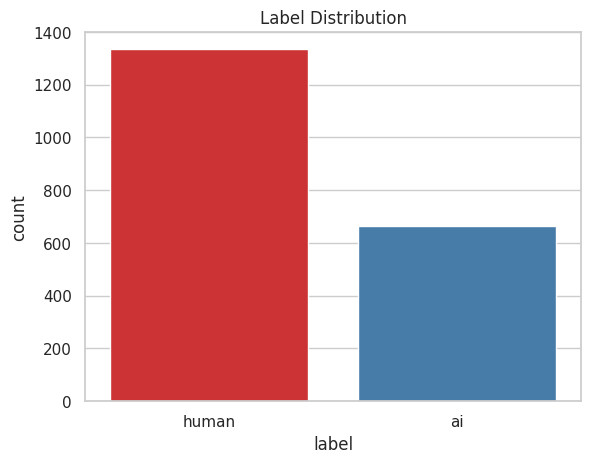

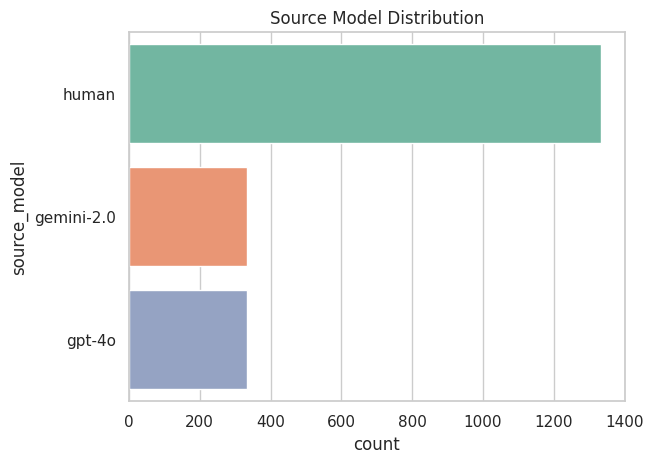

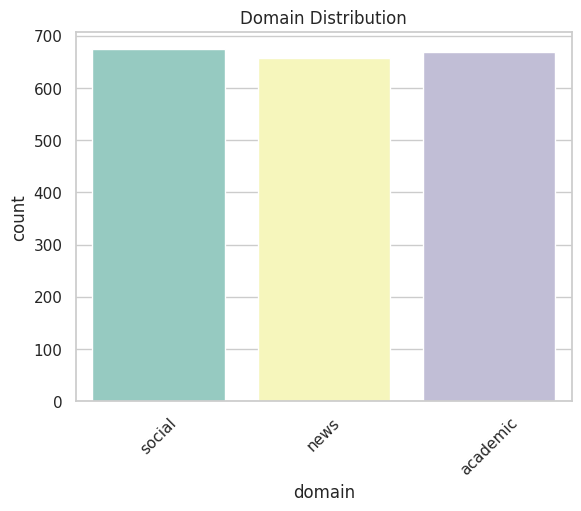

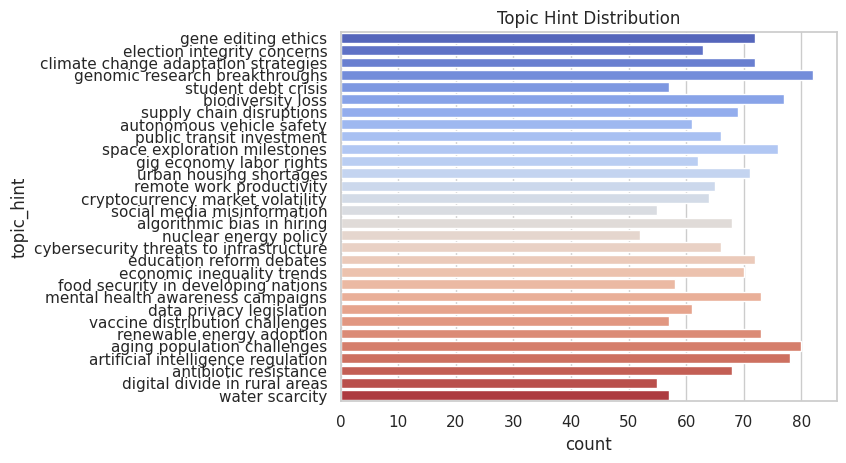

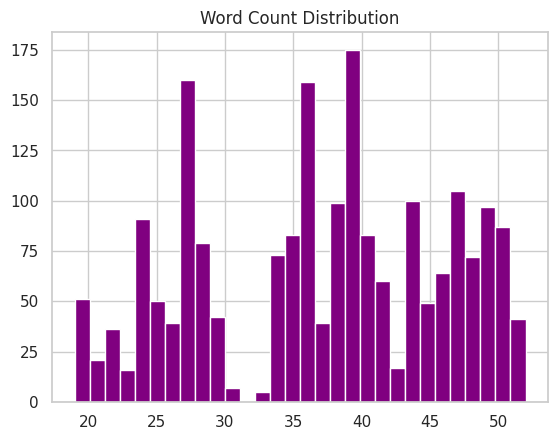

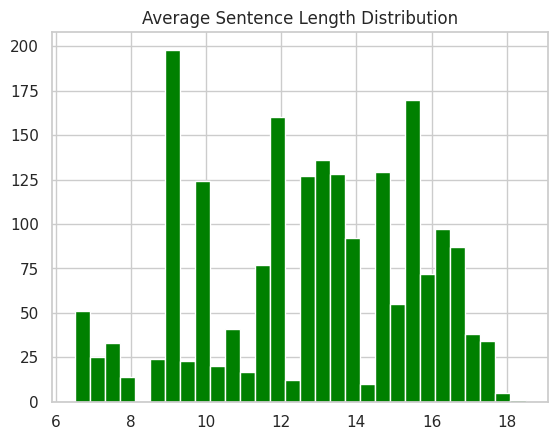

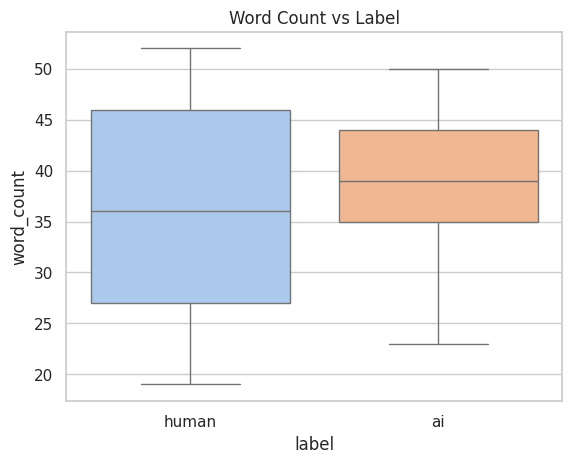

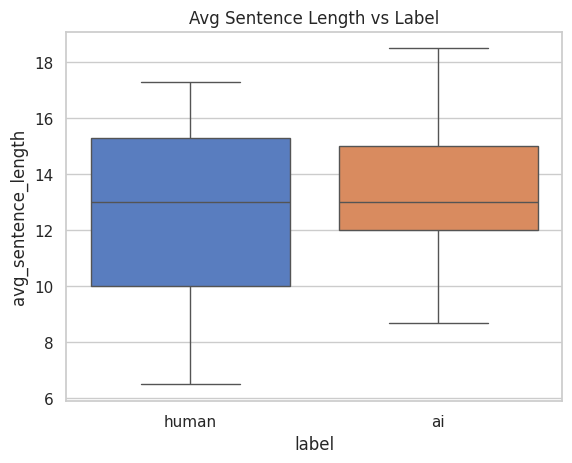

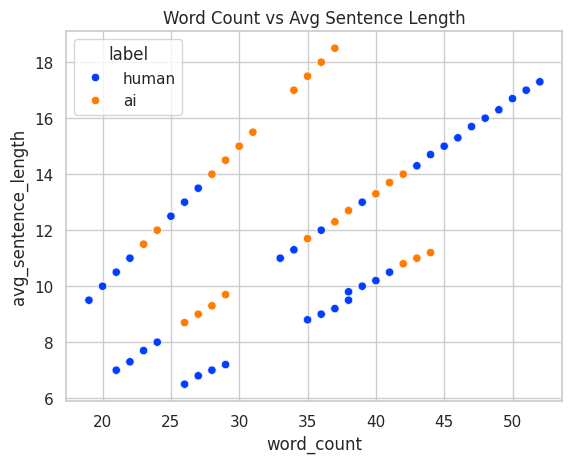

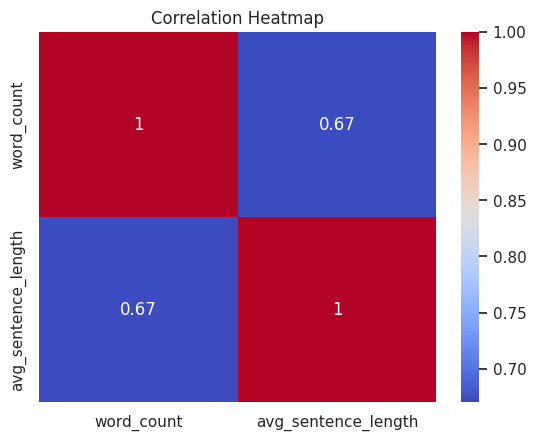

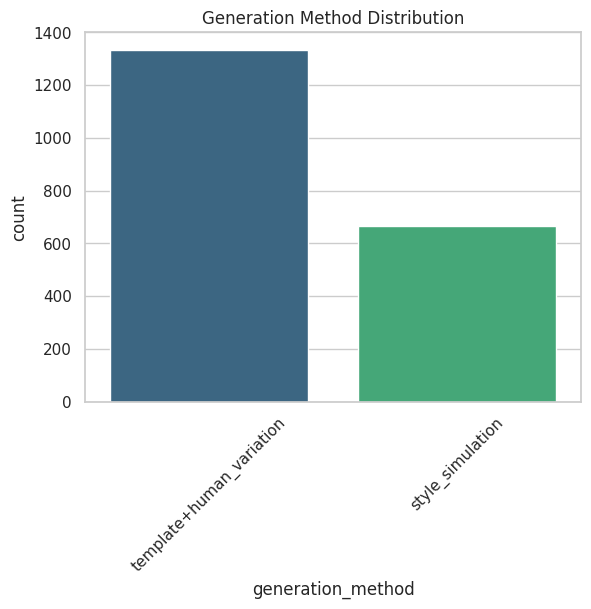

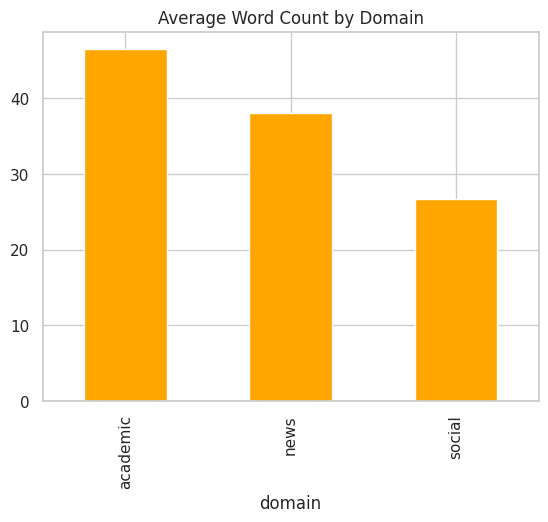

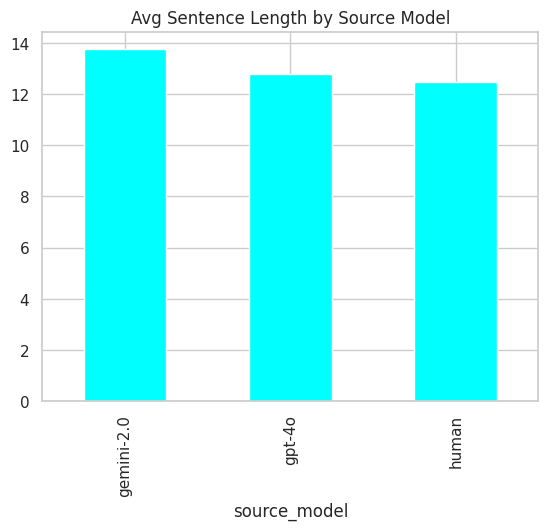

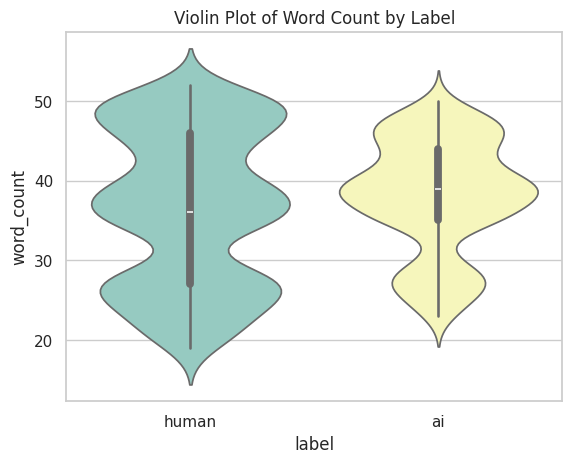

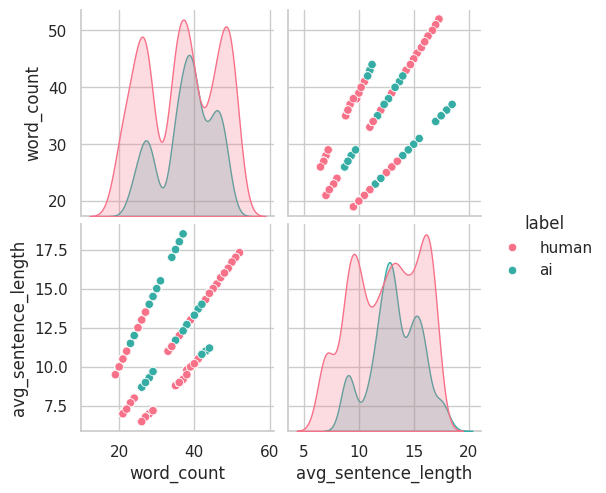

In [13]:
# Set style
sns.set(style="whitegrid")

# 1. Label Distribution
plt.figure()
sns.countplot(x='label', data=df, palette='Set1')
plt.title("Label Distribution")
plt.show()

# 2. Source Model Distribution
plt.figure()
sns.countplot(y='source_model', data=df, palette='Set2')
plt.title("Source Model Distribution")
plt.show()

# 3. Domain Distribution
plt.figure()
sns.countplot(x='domain', data=df, palette='Set3')
plt.title("Domain Distribution")
plt.xticks(rotation=45)
plt.show()

# 4. Topic Hint Distribution
plt.figure()
sns.countplot(y='topic_hint', data=df, palette='coolwarm')
plt.title("Topic Hint Distribution")
plt.show()

# 5. Word Count Histogram
plt.figure()
plt.hist(df['word_count'], bins=30, color='purple')
plt.title("Word Count Distribution")
plt.show()

# 6. Avg Sentence Length Histogram
plt.figure()
plt.hist(df['avg_sentence_length'], bins=30, color='green')
plt.title("Average Sentence Length Distribution")
plt.show()

# 7. Boxplot of Word Count by Label
plt.figure()
sns.boxplot(x='label', y='word_count', data=df, palette='pastel')
plt.title("Word Count vs Label")
plt.show()

# 8. Boxplot of Avg Sentence Length by Label
plt.figure()
sns.boxplot(x='label', y='avg_sentence_length', data=df, palette='muted')
plt.title("Avg Sentence Length vs Label")
plt.show()

# 9. Scatter Plot: Word Count vs Avg Sentence Length
plt.figure()
sns.scatterplot(x='word_count', y='avg_sentence_length', hue='label', data=df, palette='bright')
plt.title("Word Count vs Avg Sentence Length")
plt.show()

# 10. Heatmap (Correlation Matrix)
plt.figure()
corr = df[['word_count', 'avg_sentence_length']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# 11. Generation Method Distribution
plt.figure()
sns.countplot(x='generation_method', data=df, palette='viridis')
plt.title("Generation Method Distribution")
plt.xticks(rotation=45)
plt.show()

# 12. Word Count by Domain (Bar Plot)
plt.figure()
df.groupby('domain')['word_count'].mean().plot(kind='bar', color='orange')
plt.title("Average Word Count by Domain")
plt.show()

# 13. Avg Sentence Length by Source Model
plt.figure()
df.groupby('source_model')['avg_sentence_length'].mean().plot(kind='bar', color='cyan')
plt.title("Avg Sentence Length by Source Model")
plt.show()

# 14. Violin Plot (Word Count by Label)
plt.figure()
sns.violinplot(x='label', y='word_count', data=df, palette='Set3')
plt.title("Violin Plot of Word Count by Label")
plt.show()

# 15. Pairplot (Overall Feature Relationships)
sns.pairplot(df[['word_count', 'avg_sentence_length', 'label']], hue='label', palette='husl')
plt.show()

## Feature engineering


===== Logistic Regression =====
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       133
           1       1.00      1.00      1.00       267

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400


===== Random Forest =====
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       133
           1       1.00      1.00      1.00       267

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400


===== Naive Bayes =====
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       133
           1       1.00      1.00      1.00       267

    accuracy                           1.00       400
 

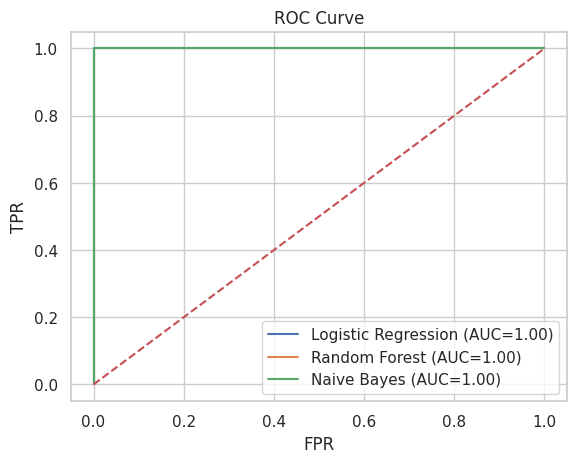

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc


target = 'label'

text_col = 'text_content'
categorical_cols = ['source_model', 'domain', 'topic_hint', 'generation_method']
numeric_cols = ['word_count', 'avg_sentence_length']

X = df.drop(columns=[target, 'text_id'])
y = df[target]

# -------------------------------
# 2. Encode Target
# -------------------------------
le = LabelEncoder()
y = le.fit_transform(y)

# -------------------------------
# 3. Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 4. Encode Categorical (NO LEAKAGE)
# -------------------------------
for col in categorical_cols:
    le_cat = LabelEncoder()
    X_train[col] = le_cat.fit_transform(X_train[col])
    X_test[col] = le_cat.transform(X_test[col])

# -------------------------------
# 5. Preprocessors
# -------------------------------

# For Logistic + RF (can handle negative values)
preprocessor_std = ColumnTransformer([
    ('text', TfidfVectorizer(max_features=5000), text_col),
    ('num', StandardScaler(), numeric_cols),
    ('cat', 'passthrough', categorical_cols)
])

# For Naive Bayes (ONLY non-negative)
preprocessor_nb = ColumnTransformer([
    ('text', TfidfVectorizer(max_features=5000), text_col),
    ('num', MinMaxScaler(), numeric_cols),  # 🔥 FIX
    ('cat', MinMaxScaler(), categorical_cols)  # 🔥 keep non-negative
])

# -------------------------------
# 6. Models with Correct Pipelines
# -------------------------------
models = {
    "Logistic Regression": Pipeline([
        ('prep', preprocessor_std),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    
    "Random Forest": Pipeline([
        ('prep', preprocessor_std),
        ('model', RandomForestClassifier(n_estimators=100))
    ]),
    
    "Naive Bayes": Pipeline([
        ('prep', preprocessor_nb),
        ('model', MultinomialNB())
    ])
}

# -------------------------------
# 7. Training & Evaluation
# -------------------------------
results = {}

for name, pipe in models.items():
    print(f"\n===== {name} =====")
    
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    
    results[name] = pipe

# -------------------------------
# 8. ROC Curve
# -------------------------------
plt.figure()

for name, pipe in results.items():
    try:
        y_prob = pipe.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")
    except:
        print(f"{name} skipped ROC")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Thank you...pls upvote!!!!!!!!!!!